### 1. Setup and Imports

In [20]:
## 1. Setup and Imports

import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Set random seed
torch.manual_seed(42)
np.random.seed(42)

# Define base data directory (change if your datasets are elsewhere)
DATA_DIR = Path("./data")   # <-- Update this to your actual data path
print(f"Looking for datasets in: {DATA_DIR.absolute()}")


Looking for datasets in: c:\Users\admin\Downloads\Source\data


### 2. Helper Functions

In [22]:
# ## 2. Helper Functions

def show_image_grid(images, titles=None, cols=4, figsize=(12,8)):
    """Display a grid of images (tensors or PIL)."""
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows > 1 or cols > 1 else [axes]
    
    for i in range(n):
        img = images[i]
        if isinstance(img, torch.Tensor):
            # Denormalize if needed (assumes mean, std)
            if img.min() < 0:
                img = (img + 1) / 2
            img = img.permute(1,2,0).clip(0,1).numpy()
        axes[i].imshow(img)
        axes[i].set_title(titles[i] if titles and i < len(titles) else f"Image {i}")
        axes[i].axis('off')
    for i in range(n, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

def compute_mean_std(dataset, num_samples=1000):
    """Approximate mean and std using a subset."""
    loader = DataLoader(Subset(dataset, range(min(num_samples, len(dataset)))), batch_size=64)
    mean = 0.0
    std = 0.0
    total_pixels = 0
    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_pixels += batch_samples
    mean /= total_pixels
    std /= total_pixels
    return mean, std

### 3. Load Tiny ImageNet

✅ Tiny ImageNet loaded: 100000 images, 200 classes


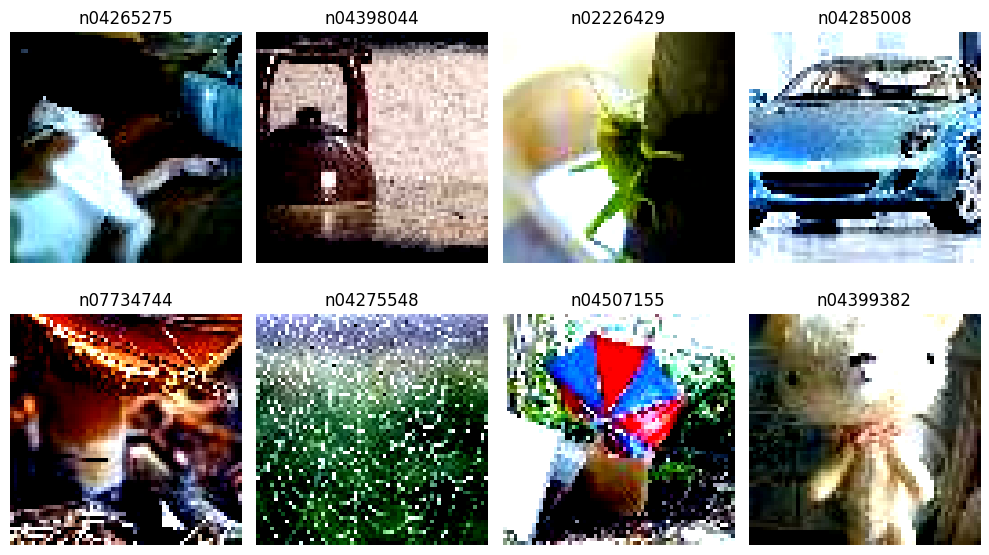

In [24]:
# ## 3. Load Tiny ImageNet (Already Downloaded)
# 
# Expected folder structure:
# ```
# data/tiny_imagenet/
#   train/
#     n01443537/   (class folder)
#       images/
#         *.JPEG
#   val/
#     images/
#     val_annotations.txt
# ```
# We'll use `torchvision.datasets.ImageFolder` for simplicity.

tiny_path = DATA_DIR / "tiny_imagenet" / "train"   # adjust if different

if tiny_path.exists():
    tiny_transform = transforms.Compose([
        transforms.Resize((64, 64)),   # ensure 64x64
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    tiny_dataset = ImageFolder(tiny_path, transform=tiny_transform)
    print(f"✅ Tiny ImageNet loaded: {len(tiny_dataset)} images, {len(tiny_dataset.classes)} classes")
else:
    print(f"❌ Tiny ImageNet not found at {tiny_path}")
    print("Please update DATA_DIR or the folder structure.")
    tiny_dataset = None

# Visualise samples
if tiny_dataset:
    sample_indices = np.random.choice(len(tiny_dataset), 8, replace=False)
    sample_images = [tiny_dataset[i][0] for i in sample_indices]
    sample_labels = [tiny_dataset.classes[tiny_dataset[i][1]] for i in sample_indices]
    show_image_grid(sample_images, titles=sample_labels, cols=4, figsize=(10,6))

### 4. Load CelebA

Found 202599 images in data\celeba\img_align_celeba
✅ CelebA loaded: 202599 images


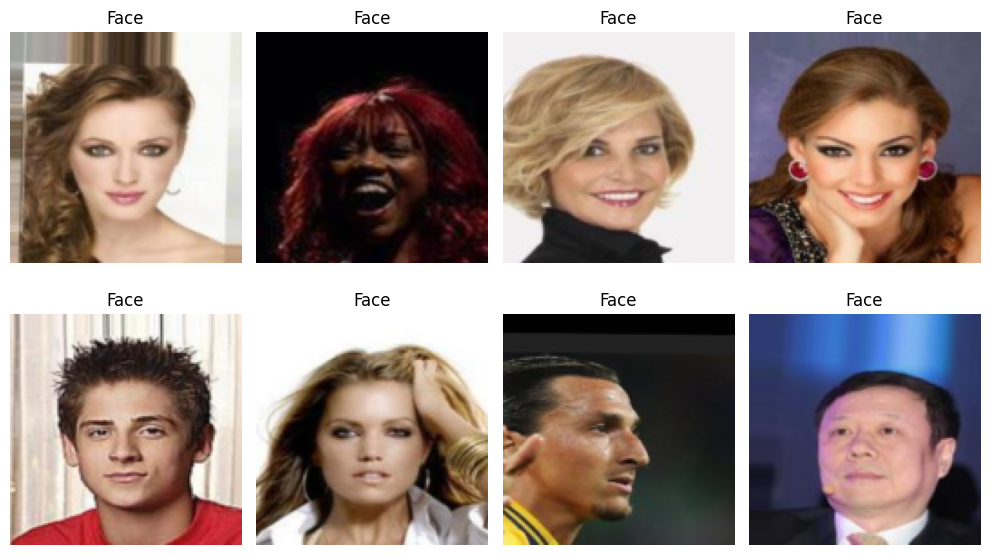

In [25]:
# ## 4. Load CelebA (Already Downloaded)
# 
# Expected folder structure:
# ```
# data/celeba/
#   img_align_celeba/   (all .jpg files)
#   list_attr_celeba.txt (optional)
# ```
# We'll create a simple custom Dataset.

class CelebALocal(Dataset):
    """CelebA dataset from local folder (already aligned & cropped)."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.img_dir = self.root_dir / "img_align_celeba"
        if not self.img_dir.exists():
            raise FileNotFoundError(f"CelebA images not found at {self.img_dir}")
        self.image_paths = sorted(list(self.img_dir.glob("*.jpg")))
        self.transform = transform
        print(f"Found {len(self.image_paths)} images in {self.img_dir}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0   # dummy label

celeba_path = DATA_DIR / "celeba"

if celeba_path.exists():
    celeba_transform = transforms.Compose([
        transforms.Resize((128, 128)),   # resize to standard size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    celeba_dataset = CelebALocal(celeba_path, transform=celeba_transform)
    print(f"✅ CelebA loaded: {len(celeba_dataset)} images")
else:
    print(f"❌ CelebA not found at {celeba_path}")
    print("Please update DATA_DIR or folder structure.")
    celeba_dataset = None

# Visualise samples
if celeba_dataset:
    sample_indices = np.random.choice(len(celeba_dataset), 8, replace=False)
    sample_images = [celeba_dataset[i][0] for i in sample_indices]
    show_image_grid(sample_images, titles=["Face"]*8, cols=4, figsize=(10,6))


### 5. Dataset Statistics Comparison

In [26]:
# ## 5. Dataset Statistics Comparison

print("\n" + "="*50)
print("DATASET COMPARISON")
print("="*50)

if tiny_dataset:
    # Optional: compute mean/std (uncomment if needed)
    # mean, std = compute_mean_std(tiny_dataset, 2000)
    # print(f"Tiny ImageNet mean: {mean}, std: {std}")
    tiny_info = {
        "Name": "Tiny ImageNet",
        "Images": len(tiny_dataset),
        "Resolution": "64×64",
        "Classes": len(tiny_dataset.classes),
        "Location": str(tiny_path)
    }
    for k, v in tiny_info.items():
        print(f"{k:12}: {v}")
    print("-"*40)

if celeba_dataset:
    celeba_info = {
        "Name": "CelebA",
        "Images": len(celeba_dataset),
        "Resolution": "128×128 (resized)",
        "Classes": "Faces (no class labels)",
        "Location": str(celeba_path / "img_align_celeba")
    }
    for k, v in celeba_info.items():
        print(f"{k:12}: {v}")


DATASET COMPARISON
Name        : Tiny ImageNet
Images      : 100000
Resolution  : 64×64
Classes     : 200
Location    : data\tiny_imagenet\train
----------------------------------------
Name        : CelebA
Images      : 202599
Resolution  : 128×128 (resized)
Classes     : Faces (no class labels)
Location    : data\celeba\img_align_celeba


### 6. Prepare Image Pairs for Steganography

Tiny ImageNet pairs: 100000
Cover shape: torch.Size([3, 64, 64]), Secret shape: torch.Size([3, 64, 64])


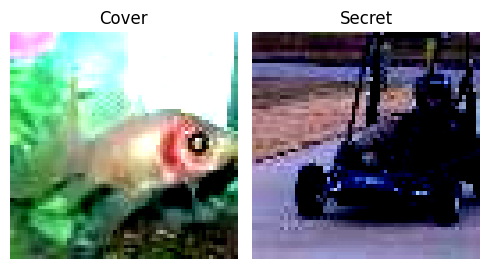

CelebA pairs: 202599
Cover shape: torch.Size([3, 128, 128]), Secret shape: torch.Size([3, 128, 128])


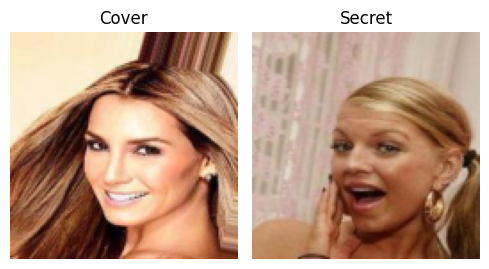

In [ ]:
# ## 6. Prepare Image Pairs for Steganography
# 
# We need random (cover, secret) pairs from the same dataset.

class SteganoPairDataset(Dataset):
    """Returns (cover, secret) pair from a given dataset."""
    def __init__(self, dataset):
        self.dataset = dataset
        self.length = len(dataset)
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        cover_img, _ = self.dataset[idx]
        # Pick a different image for secret
        secret_idx = (idx + torch.randint(1, self.length, (1,)).item()) % self.length
        secret_img, _ = self.dataset[secret_idx]
        return cover_img, secret_img

# Create paired datasets
if tiny_dataset:
    tiny_pairs = SteganoPairDataset(tiny_dataset)
    print(f"Tiny ImageNet pairs: {len(tiny_pairs)}")
    cover, secret = tiny_pairs[0]
    print(f"Cover shape: {cover.shape}, Secret shape: {secret.shape}")
    show_image_grid([cover, secret], titles=["Cover", "Secret"], cols=2, figsize=(5,5))

if celeba_dataset:
    celeba_pairs = SteganoPairDataset(celeba_dataset)
    print(f"CelebA pairs: {len(celeba_pairs)}")
    cover, secret = celeba_pairs[0]
    print(f"Cover shape: {cover.shape}, Secret shape: {secret.shape}")
    show_image_grid([cover, secret], titles=["Cover", "Secret"], cols=2, figsize=(5,5))
